<a href="https://colab.research.google.com/github/thanhtam160603/CLARANS-Clustering-Analysis/blob/main/DataMining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
## Kết nối Google Drive
from google.colab import drive
drive.mount('/content/gdrive', force_remount = True)
folder = '/content/gdrive/My Drive/Colab Notebooks/kpdlFinal'

Mounted at /content/gdrive


5 DÒNG ĐẦU TIÊN
   id  battery_power  blue  clock_speed  dual_sim  fc  four_g  int_memory  \
0   1         1043.0     1          1.8         1  14       0           5   
1   2          841.0     1          0.5         1   4       1          61   
2   3         1807.0     1          2.8         0   1       0          27   
3   4         1546.0     0          0.5         1  18       1          25   
4   5         1434.0     0          1.4         0  11       1          49   

   m_dep  mobile_wt  ...  pc  px_height  px_width   ram  sc_h  sc_w  \
0    0.1      193.0  ...  16        226      1412  3476    12     7   
1    0.8      191.0  ...  12        746       857  3895     6     0   
2    0.9      143.5  ...   4       1270      1366  2396    17    10   
3    0.5       96.0  ...  20        295      1752  3893    10     0   
4    0.5      108.0  ...  18        749       810  1773    15     8   

   talk_time  three_g  touch_screen  wifi  
0          2        0             1     0  
1     

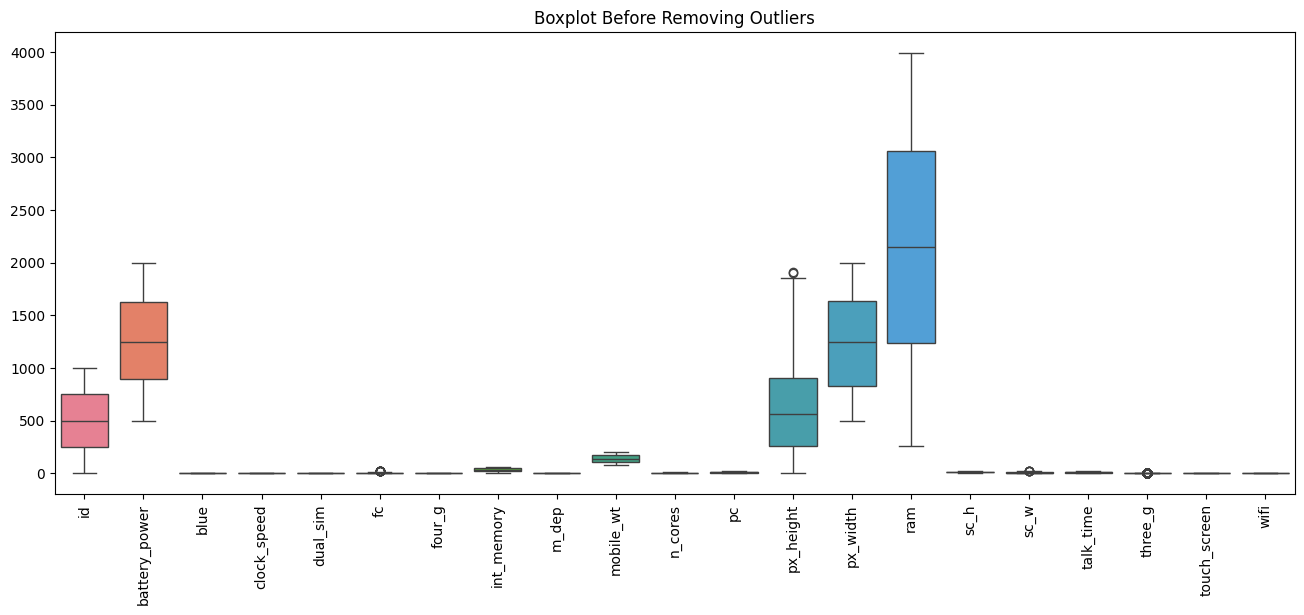


OUTLIER DETECTION
Outlier indexes: []
Outlier values: []

Dữ liệu sau khi remove outliers:
(1000, 21)

NORMALIZATION
Shape: (1000, 21)

Đã lưu clean_test1.csv

SILHOUETTE EVALUATION

Silhouette Scores:
[np.float64(0.04368827940627351), np.float64(0.023209446828568504), np.float64(0.02512050387946838), np.float64(0.017873999116548717), np.float64(0.021162659282959028), np.float64(0.021682112899577218), np.float64(0.020690624724283076), np.float64(0.024442002095790952), np.float64(0.008114241179717688)]

Best K: 2


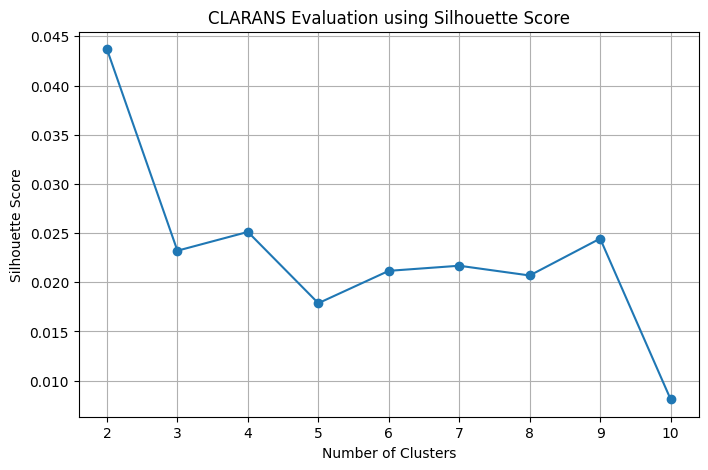


TRAIN FINAL MODEL

Kết quả gom cụm:
         id  battery_power      blue  clock_speed  dual_sim        fc  \
0 -1.730320      -0.473226  0.968496     0.312601  0.966559  2.108676   
1 -1.726856      -0.941210  0.968496    -1.255832  0.966559 -0.132927   
2 -1.723391       1.296771  0.968496     1.519087 -1.034598 -0.805408   
3 -1.719927       0.692099 -1.032529    -1.255832  0.966559  3.005317   
4 -1.716463       0.432623 -1.032529    -0.169994 -1.034598  1.436195   
5 -1.712999       0.502125  0.968496     1.639736  0.966559  0.091233   
6 -1.709535      -0.000609 -1.032529     1.036493 -1.034598 -0.805408   
7 -1.706071      -0.959744 -1.032529     1.036493  0.966559 -1.029568   
8 -1.702607      -0.315687  0.968496     1.639736  0.966559  0.987874   
9 -1.699143       0.631863 -1.032529    -1.255832 -1.034598 -0.805408   

     four_g  int_memory     m_dep  mobile_wt  ...  px_height  px_width  \
0 -0.974329   -1.581269 -1.487247   1.537827  ...  -0.926990  0.391912   
1  1.026347

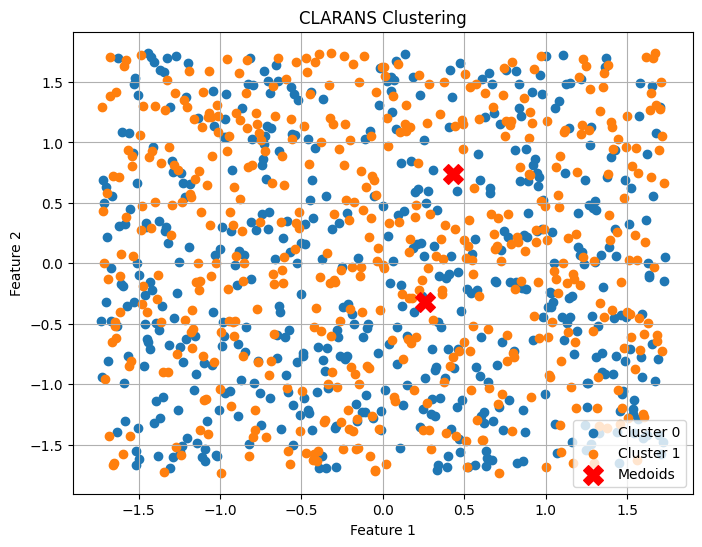


Đã xuất file clarans_result.csv

HOÀN THÀNH PROJECT CLARANS


In [3]:
# =========================================================
# CLARANS CLUSTERING PROJECT - FULL VERSION
# =========================================================

# =========================================================
# IMPORT LIBRARIES
# =========================================================

import pandas as pd
import numpy as np
import scipy as scp
import seaborn as sbn
import matplotlib.pyplot as plt
import joblib as jlb
import warnings

warnings.filterwarnings('ignore')

from scipy.spatial.distance import cdist

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score


# =========================================================
# RANDOM SEED
# =========================================================

np.random.seed(42)


# =========================================================
# READ DATA
# =========================================================

df = pd.read_csv(folder + '/test1.csv')

print('=' * 60)
print('5 DÒNG ĐẦU TIÊN')
print('=' * 60)

print(df.head())


# =========================================================
# CHECK MISSING VALUES
# =========================================================

print('\n' + '=' * 60)
print('SỐ LƯỢNG GIÁ TRỊ THIẾU')
print('=' * 60)

print(len(df) - df.count())

print(
    '\nMissing [battery_power]:',
    len(df[df['battery_power'].isnull()])
)

print(
    'Missing [mobile_wt]:',
    len(df[df['mobile_wt'].isnull()])
)


# =========================================================
# HANDLE MISSING VALUES
# =========================================================

print('\n' + '=' * 60)
print('XỬ LÝ GIÁ TRỊ THIẾU')
print('=' * 60)

# Fill mean
battery_mean = round(df['battery_power'].mean())

df['battery_power'] = df['battery_power'].fillna(
    battery_mean
)

# Linear interpolation
df['mobile_wt'] = df['mobile_wt'].interpolate()

print(
    df[['battery_power', 'mobile_wt']].head(10)
)


# =========================================================
# REMOVE DUPLICATES
# =========================================================

print('\n' + '=' * 60)
print('DỮ LIỆU TRƯỚC KHI XÓA DUPLICATE')
print('=' * 60)

print(df.shape)

df = df.drop_duplicates()

print('\nDỮ LIỆU SAU KHI XÓA DUPLICATE')

print(df.shape)


# =========================================================
# SELECT NUMERIC COLUMNS
# =========================================================

df = df.select_dtypes(include=[np.number])


# =========================================================
# VISUALIZE OUTLIERS
# =========================================================

print('\n' + '=' * 60)
print('BOXPLOT')
print('=' * 60)

plt.figure(figsize=(16, 6))

sbn.boxplot(data=df)

plt.xticks(rotation=90)

plt.title('Boxplot Before Removing Outliers')

plt.show()


# =========================================================
# OUTLIER DETECTION
# =========================================================

print('\n' + '=' * 60)
print('OUTLIER DETECTION')
print('=' * 60)

data_z = scp.stats.zscore(
    df['battery_power'],
    ddof=1
)

radius = 3

indexes = np.where(
    np.abs(data_z) > radius
)[0]

print('Outlier indexes:', indexes)

print(
    'Outlier values:',
    df.iloc[indexes]['battery_power'].tolist()
)


# =========================================================
# REMOVE OUTLIERS
# =========================================================

df = df[
    np.abs(data_z) < radius
]

print('\nDữ liệu sau khi remove outliers:')

print(df.shape)


# =========================================================
# NORMALIZATION
# =========================================================

print('\n' + '=' * 60)
print('NORMALIZATION')
print('=' * 60)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

print('Shape:', X_scaled.shape)


# =========================================================
# SAVE CLEAN DATA
# =========================================================

clean_df = pd.DataFrame(
    X_scaled,
    columns=df.columns
)

clean_df.to_csv(
    folder + '/clean_test1.csv',
    index=False
)

print('\nĐã lưu clean_test1.csv')


# =========================================================
# CLARANS CLASS
# =========================================================

class CLARANS:

    def __init__(
        self,
        data,
        num_clusters,
        max_neighbor,
        num_local
    ):

        self.data = data

        self.num_clusters = num_clusters

        self.max_neighbor = max_neighbor

        self.num_local = num_local

        self.num_samples, self.num_features = data.shape

        self.medoids = []


    # =====================================================
    # TRAIN MODEL
    # =====================================================

    def fit(self):

        # Random medoids
        self.medoids = np.random.choice(
            self.num_samples,
            self.num_clusters,
            replace=False
        )

        best_cost = self._get_total_cost(
            self.medoids
        )

        # Local search
        for _ in range(self.num_local):

            neighbor_counter = 0

            while neighbor_counter < self.max_neighbor:

                current_medoids = self.medoids.copy()

                # Non medoids
                non_medoids = np.setdiff1d(
                    np.arange(self.num_samples),
                    current_medoids
                )

                # Random non-medoid
                random_non_medoid = np.random.choice(
                    non_medoids
                )

                # Replace medoid
                replace_index = np.random.randint(
                    0,
                    self.num_clusters
                )

                current_medoids[
                    replace_index
                ] = random_non_medoid

                # New cost
                new_cost = self._get_total_cost(
                    current_medoids
                )

                # Better solution
                if new_cost < best_cost:

                    self.medoids = current_medoids

                    best_cost = new_cost

                    # Reset neighbor counter
                    neighbor_counter = 0

                else:

                    neighbor_counter += 1

        clusters = self._assign_clusters(
            self.medoids
        )

        return clusters


    # =====================================================
    # TOTAL COST
    # =====================================================

    def _get_total_cost(self, medoids):

        distances = cdist(
            self.data,
            self.data[medoids]
        )

        min_distances = np.min(
            distances,
            axis=1
        )

        return np.sum(min_distances)


    # =====================================================
    # ASSIGN CLUSTERS
    # =====================================================

    def _assign_clusters(self, medoids):

        distances = cdist(
            self.data,
            self.data[medoids]
        )

        return np.argmin(
            distances,
            axis=1
        )


# =========================================================
# SILHOUETTE EVALUATION
# =========================================================

def evaluate_clarans(
    data,
    k_range,
    max_neighbor,
    num_local
):

    scores = []

    for k in k_range:

        model = CLARANS(
            data=data,
            num_clusters=k,
            max_neighbor=max_neighbor,
            num_local=num_local
        )

        labels = model.fit()

        try:

            score = silhouette_score(
                data,
                labels
            )

        except:

            score = -1

        scores.append(score)

    return scores


# =========================================================
# PARAMETERS
# =========================================================

k_range = range(2, 11)

max_neighbor = 6

num_local = 2


# =========================================================
# EVALUATE CLARANS
# =========================================================

print('\n' + '=' * 60)
print('SILHOUETTE EVALUATION')
print('=' * 60)

silhouette_scores = evaluate_clarans(
    X_scaled,
    k_range,
    max_neighbor,
    num_local
)

print('\nSilhouette Scores:')

print(silhouette_scores)


# =========================================================
# BEST K
# =========================================================

best_k = list(k_range)[
    np.argmax(silhouette_scores)
]

print('\nBest K:', best_k)


# =========================================================
# PLOT SILHOUETTE
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    list(k_range),
    silhouette_scores,
    marker='o'
)

plt.xlabel('Number of Clusters')

plt.ylabel('Silhouette Score')

plt.title(
    'CLARANS Evaluation using Silhouette Score'
)

plt.grid(True)

plt.show()


# =========================================================
# TRAIN FINAL MODEL
# =========================================================

print('\n' + '=' * 60)
print('TRAIN FINAL MODEL')
print('=' * 60)

clarans = CLARANS(
    data=X_scaled,
    num_clusters=best_k,
    max_neighbor=max_neighbor,
    num_local=num_local
)

clusters = clarans.fit()


# =========================================================
# ADD CLUSTER COLUMN
# =========================================================

result = clean_df.copy()

result['Cluster'] = clusters

print('\nKết quả gom cụm:')

print(result.head(10))


# =========================================================
# CLUSTER STATISTICS
# =========================================================

unique_clusters, counts = np.unique(
    result['Cluster'],
    return_counts=True
)

cluster_counts = pd.DataFrame({

    'Cluster': unique_clusters,

    'Count': counts
})

print('\nKích thước các cluster:')

print(cluster_counts)

largest_cluster = unique_clusters[
    np.argmax(counts)
]

print('\nCluster lớn nhất:')

print(largest_cluster)


# =========================================================
# SAVE MODEL
# =========================================================

jlb.dump(
    clarans,
    folder + '/clarans.pkl'
)

print('\nĐã lưu model: clarans.pkl')


# =========================================================
# LOAD MODEL
# =========================================================

loaded_model = jlb.load(
    folder + '/clarans.pkl'
)

print('\nMedoids:')

print(loaded_model.medoids)


# =========================================================
# VISUALIZATION
# =========================================================

print('\n' + '=' * 60)
print('VISUALIZATION')
print('=' * 60)

plt.figure(figsize=(8, 6))

for cluster in range(best_k):

    cluster_data = result[
        result['Cluster'] == cluster
    ]

    plt.scatter(
        cluster_data.iloc[:, 0],
        cluster_data.iloc[:, 1],
        label=f'Cluster {cluster}'
    )

# Medoid points
medoid_points = X_scaled[
    clarans.medoids
]

plt.scatter(
    medoid_points[:, 0],
    medoid_points[:, 1],
    marker='X',
    s=200,
    color='red',
    label='Medoids'
)

plt.xlabel('Feature 1')

plt.ylabel('Feature 2')

plt.title('CLARANS Clustering')

plt.legend()

plt.grid(True)

plt.show()


# =========================================================
# EXPORT RESULT CSV
# =========================================================

result.to_csv(
    folder + '/clarans_result.csv',
    index=False
)

print('\nĐã xuất file clarans_result.csv')


# =========================================================
# FINISH
# =========================================================

print('\n' + '=' * 60)
print('HOÀN THÀNH PROJECT CLARANS')
print('=' * 60)